In [1]:

# ============================================================
# Schmidt Stability Forecasting:
# 1) Recursive LSTM
# 2) Recursive LSTM-XGBoost residual correction
# 3) Persistence
#
# History: 56 x 3-hour steps = 7 days
# Horizon: 16 x 3-hour steps = 48 hours
# Issue frequency: every 3 hours
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import random
import joblib

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
except ImportError as exc:
    raise ImportError(
        "xgboost is not installed. Run: pip install xgboost"
    ) from exc

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


# ============================================================
# 0. REPRODUCIBILITY AND DISPLAY
# ============================================================

mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["font.size"] = 15

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# 1. FILES AND SETTINGS
# ============================================================

DATA_DIR = Path(
    r"C:/Users/sh1345/code/myproject/Project 1/data/weather data"
)

OBS_FILE = Path("gap filled data.xlsx")
AIRPORT_FILE = DATA_DIR / "airport_weather_3hourly_2007_to_2023.csv"
OPENMETEO_FILE = DATA_DIR / (
    "openmeteo_bias_corrected_3hourly_forecast_period_2023_onward.csv"
)

OUTPUT_DIR = Path(
    "recursive_lstm_xgboost_outputs/history56_horizon16_3hourly_reduced_weather"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FORECAST_STEP_HOURS = 3
EXPECTED_FREQ = pd.Timedelta(hours=FORECAST_STEP_HOURS)

HISTORY_STEPS = 56
FORECAST_HORIZON_STEPS = 16
ISSUE_FREQUENCY_STEPS = 1

train_start = None
train_end = pd.Timestamp("2018-11-30 23:59:59")

val_start = pd.Timestamp("2018-12-01 00:00:00")
val_end = pd.Timestamp("2023-02-28 23:59:59")

forecast_start = pd.Timestamp("2023-03-01 00:00:00")
forecast_end = None

# Split validation for leakage-free XGBoost development:
# - XGB residual training: 2018-12 to 2021-12
# - Hybrid validation: 2022-01 to 2023-02
XGB_RESIDUAL_TRAIN_END = pd.Timestamp("2021-12-31 23:59:59")
HYBRID_VALIDATION_START = pd.Timestamp("2022-01-01 00:00:00")

USE_LOG_TARGET = False

LSTM_UNITS_1 = 32
LSTM_UNITS_2 = 16
DROPOUT_RATE = 0.30
DENSE_UNITS = 8
LEARNING_RATE = 5e-4

BATCH_SIZE = 32
EPOCHS = 100
EARLY_STOP_PATIENCE = 8
LR_PATIENCE = 4

# Reduced weather set selected from your comparison
WEATHER_COLS = [
    "air_temperature_deg_c",
    "relative_humidity_percent",
    "wind_speed_m_s",
    "radiation_w_m2",
]

# XGBoost settings
XGB_PARAMS = {
    "n_estimators": 500,
    "learning_rate": 0.03,
    "max_depth": 4,
    "min_child_weight": 5,
    "subsample": 0.80,
    "colsample_bytree": 0.80,
    "reg_alpha": 0.0,
    "reg_lambda": 2.0,
    "objective": "reg:squarederror",
    "random_state": SEED,
    "n_jobs": -1,
}

In [2]:



# ============================================================
# 2. HELPERS
# ============================================================

def print_heading(title):
    print("\n" + "=" * 88)
    print(title)
    print("=" * 88)


def evaluate_regression(y_true, y_pred, label=None, verbose=True):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    error = y_pred - y_true

    metrics = {
        "n": len(y_true),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)) if len(y_true) > 1 else np.nan,
        "Bias": float(np.mean(error)),
    }

    if verbose:
        print(f"\n{label or 'Metrics'}")
        print("-" * 42)
        for key, value in metrics.items():
            if key == "n":
                print(f"{key:5s}: {value}")
            else:
                print(f"{key:5s}: {value:.4f}")

    return metrics


def add_datetime_features(df, dt_col="datetime"):
    out = df.copy()

    hour = out[dt_col].dt.hour
    doy = out[dt_col].dt.dayofyear

    out["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    out["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    out["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    out["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)

    return out


def inverse_s(s_scaled, scaler, s_col_idx, use_log_target=False):
    s_scaled = np.asarray(s_scaled, dtype=float)
    s_unscaled = (
        s_scaled * scaler.scale_[s_col_idx]
        + scaler.mean_[s_col_idx]
    )

    if use_log_target:
        s_unscaled = np.expm1(s_unscaled)

    return s_unscaled


def add_error_columns(df, pred_col="y_pred"):
    out = df.copy()
    out["error"] = out[pred_col] - out["y_true"]
    out["abs_error"] = out["error"].abs()
    out["squared_error"] = out["error"] ** 2
    return out


def summarize_predictions_by_lead(results, prediction_cols):
    rows = []

    for pred_col, model_name in prediction_cols.items():
        for lead_step, group in results.groupby("lead_step"):
            metrics = evaluate_regression(
                group["y_true"],
                group[pred_col],
                verbose=False,
            )

            rows.append({
                "model": model_name,
                "lead_step": int(lead_step),
                "lead_hours": int(lead_step * FORECAST_STEP_HOURS),
                **metrics,
            })

    return pd.DataFrame(rows)


def overall_metrics_table(results, prediction_cols, set_name):
    rows = []

    for pred_col, model_name in prediction_cols.items():
        metrics = evaluate_regression(
            results["y_true"],
            results[pred_col],
            verbose=False,
        )
        rows.append({
            "set": set_name,
            "model": model_name,
            **metrics,
        })

    return pd.DataFrame(rows)


def peak_metrics_table(results, prediction_cols, peak_threshold, set_name):
    peak = results.loc[results["y_true"] >= peak_threshold].copy()
    rows = []

    if peak.empty:
        return pd.DataFrame()

    for pred_col, model_name in prediction_cols.items():
        metrics = evaluate_regression(
            peak["y_true"],
            peak[pred_col],
            verbose=False,
        )
        rows.append({
            "set": set_name,
            "model": model_name,
            "peak_threshold": peak_threshold,
            **metrics,
        })

    return pd.DataFrame(rows)

In [3]:



# ============================================================
# 3. LOAD AND MERGE DATA
# ============================================================

print_heading("LOADING DATA")

for required_file in [OBS_FILE, AIRPORT_FILE, OPENMETEO_FILE]:
    if not required_file.exists():
        raise FileNotFoundError(
            f"Required file not found: {required_file.resolve()}"
        )

obs = pd.read_excel(OBS_FILE)
obs.columns = obs.columns.str.strip()
obs["datetime"] = pd.to_datetime(obs["datetime"], errors="coerce")
obs = (
    obs.dropna(subset=["datetime"])
    .sort_values("datetime")
    .drop_duplicates("datetime", keep="last")
    .reset_index(drop=True)
)

if "S" not in obs.columns:
    raise KeyError("The Schmidt stability file must contain column 'S'.")

airport = pd.read_csv(AIRPORT_FILE)
airport.columns = airport.columns.str.strip()
airport = airport.rename(columns={"datetime_NZ": "datetime"})
airport["datetime"] = pd.to_datetime(airport["datetime"], errors="coerce")

openmeteo = pd.read_csv(OPENMETEO_FILE)
openmeteo.columns = openmeteo.columns.str.strip()
openmeteo = openmeteo.rename(columns={"datetime_NZ": "datetime"})
openmeteo["datetime"] = pd.to_datetime(
    openmeteo["datetime"], errors="coerce"
)

for name, weather_df in [
    ("Airport", airport),
    ("Open-Meteo", openmeteo),
]:
    required = ["datetime"] + WEATHER_COLS
    missing = [col for col in required if col not in weather_df.columns]
    if missing:
        raise KeyError(f"{name} file is missing columns: {missing}")

airport = (
    airport[["datetime"] + WEATHER_COLS]
    .dropna(subset=["datetime"])
    .sort_values("datetime")
    .drop_duplicates("datetime", keep="last")
)

openmeteo = (
    openmeteo[["datetime"] + WEATHER_COLS]
    .dropna(subset=["datetime"])
    .sort_values("datetime")
    .drop_duplicates("datetime", keep="last")
)

airport_period = airport.loc[
    airport["datetime"] < forecast_start
].copy()
airport_period["weather_source"] = "Airport"

openmeteo_period = openmeteo.loc[
    openmeteo["datetime"] >= forecast_start
].copy()
openmeteo_period["weather_source"] = "OpenMeteo_bias_corrected"

weather = (
    pd.concat([airport_period, openmeteo_period], ignore_index=True)
    .sort_values("datetime")
    .drop_duplicates("datetime", keep="last")
    .reset_index(drop=True)
)

df = (
    obs[["datetime", "S"]]
    .merge(weather, on="datetime", how="inner")
    .sort_values("datetime")
    .reset_index(drop=True)
)

if train_start is None:
    train_start = df["datetime"].min()

if forecast_end is None:
    forecast_end = df["datetime"].max()
else:
    forecast_end = min(
        pd.Timestamp(forecast_end),
        df["datetime"].max(),
    )

df = df.loc[
    df["datetime"].between(train_start, forecast_end)
].copy().reset_index(drop=True)

time_diffs = df["datetime"].diff().dropna()
bad_steps = time_diffs.loc[time_diffs != EXPECTED_FREQ]

if not bad_steps.empty:
    raise ValueError(
        f"Merged data are not a complete 3-hour grid. "
        f"Irregular intervals: {len(bad_steps)}"
    )

df["S_model"] = np.log1p(df["S"]) if USE_LOG_TARGET else df["S"]
df = add_datetime_features(df)

TIME_FEATURE_COLS = [
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",
]

HISTORY_FEATURE_COLS = [
    "S_model",
    *WEATHER_COLS,
    *TIME_FEATURE_COLS,
]

FUTURE_FEATURE_COLS = [
    *WEATHER_COLS,
    *TIME_FEATURE_COLS,
]

S_COL_IDX = HISTORY_FEATURE_COLS.index("S_model")

required_model_cols = list(dict.fromkeys([
    "datetime",
    "S",
    "S_model",
    *HISTORY_FEATURE_COLS,
    *FUTURE_FEATURE_COLS,
]))

missing_values = df[required_model_cols].isna().sum()
if missing_values.any():
    raise ValueError(
        "Missing model values:\n"
        + missing_values[missing_values > 0].to_string()
    )

model_df = df[required_model_cols].copy()

print("Rows:", len(model_df))
print("Range:", model_df["datetime"].min(), "to", model_df["datetime"].max())
print("Weather features:", WEATHER_COLS)
print("History hours:", HISTORY_STEPS * FORECAST_STEP_HOURS)
print("Forecast hours:", FORECAST_HORIZON_STEPS * FORECAST_STEP_HOURS)


LOADING DATA
Rows: 54536
Range: 2007-07-13 12:00:00 to 2026-03-12 09:00:00
Weather features: ['air_temperature_deg_c', 'relative_humidity_percent', 'wind_speed_m_s', 'radiation_w_m2']
History hours: 168
Forecast hours: 48


In [4]:



# ============================================================
# 4. DATA SPLITS AND SCALING
# ============================================================

train_df = model_df.loc[
    model_df["datetime"].between(train_start, train_end)
].copy()

val_df = model_df.loc[
    model_df["datetime"].between(val_start, val_end)
].copy()

test_df = model_df.loc[
    model_df["datetime"].between(forecast_start, forecast_end)
].copy()

for name, part in [
    ("Training", train_df),
    ("Validation", val_df),
    ("Test", test_df),
]:
    if part.empty:
        raise ValueError(f"{name} period is empty.")

print_heading("DATA SPLITS")
print("Training  :", train_df["datetime"].min(), "to", train_df["datetime"].max())
print("Validation:", val_df["datetime"].min(), "to", val_df["datetime"].max())
print("Test      :", test_df["datetime"].min(), "to", test_df["datetime"].max())

history_scaler = StandardScaler()
future_scaler = StandardScaler()

history_scaler.fit(train_df[HISTORY_FEATURE_COLS].astype(float))
future_scaler.fit(train_df[FUTURE_FEATURE_COLS].astype(float))

model_df_scaled = model_df.copy()
model_df_scaled[HISTORY_FEATURE_COLS] = history_scaler.transform(
    model_df[HISTORY_FEATURE_COLS].astype(float)
)
model_df_scaled[FUTURE_FEATURE_COLS] = future_scaler.transform(
    model_df[FUTURE_FEATURE_COLS].astype(float)
)


# ============================================================
# 5. ONE-STEP SEQUENCES
# ============================================================

def build_one_step_sequences(
    full_df_scaled,
    start_dt,
    end_dt,
):
    X_hist = []
    X_future = []
    y = []
    meta = []

    data = full_df_scaled.sort_values("datetime").reset_index(drop=True)

    for target_idx in range(HISTORY_STEPS, len(data)):
        target_dt = data.loc[target_idx, "datetime"]

        if target_dt < start_dt:
            continue
        if end_dt is not None and target_dt > end_dt:
            continue

        issue_idx = target_idx - 1

        history = data.loc[
            target_idx - HISTORY_STEPS:issue_idx,
            HISTORY_FEATURE_COLS,
        ]

        future = data.loc[target_idx, FUTURE_FEATURE_COLS]

        X_hist.append(history.to_numpy(dtype=np.float32))
        X_future.append(future.to_numpy(dtype=np.float32))
        y.append(float(data.loc[target_idx, "S_model"]))

        meta.append({
            "issue_datetime": data.loc[issue_idx, "datetime"],
            "target_datetime": target_dt,
        })

    return (
        np.asarray(X_hist, dtype=np.float32),
        np.asarray(X_future, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        pd.DataFrame(meta),
    )


X_train_hist, X_train_future, y_train, train_meta = (
    build_one_step_sequences(
        model_df_scaled,
        train_start,
        train_end,
    )
)

X_val_hist, X_val_future, y_val, val_meta = (
    build_one_step_sequences(
        model_df_scaled,
        val_start,
        val_end,
    )
)

print_heading("ONE-STEP SEQUENCE SHAPES")
print("X_train_hist  :", X_train_hist.shape)
print("X_train_future:", X_train_future.shape)
print("y_train       :", y_train.shape)
print("X_val_hist    :", X_val_hist.shape)
print("X_val_future  :", X_val_future.shape)
print("y_val         :", y_val.shape)


DATA SPLITS
Training  : 2007-07-13 12:00:00 to 2018-11-30 21:00:00
Validation: 2018-12-01 00:00:00 to 2023-02-28 21:00:00
Test      : 2023-03-01 00:00:00 to 2026-03-12 09:00:00

ONE-STEP SEQUENCE SHAPES
X_train_hist  : (33212, 56, 9)
X_train_future: (33212, 8)
y_train       : (33212,)
X_val_hist    : (12408, 56, 9)
X_val_future  : (12408, 8)
y_val         : (12408,)


In [5]:



# ============================================================
# 6. BUILD AND TRAIN LSTM
# ============================================================

def build_lstm_model():
    history_input = Input(
        shape=(HISTORY_STEPS, len(HISTORY_FEATURE_COLS)),
        name="history_input",
    )

    x = LSTM(
        LSTM_UNITS_1,
        return_sequences=True,
    )(history_input)
    x = Dropout(DROPOUT_RATE)(x)

    x = LSTM(
        LSTM_UNITS_2,
        return_sequences=False,
    )(x)
    x = Dropout(DROPOUT_RATE)(x)

    future_input = Input(
        shape=(len(FUTURE_FEATURE_COLS),),
        name="future_input",
    )

    z = Dense(DENSE_UNITS, activation="relu")(future_input)
    z = Dropout(DROPOUT_RATE)(z)

    combined = Concatenate()([x, z])
    combined = Dense(DENSE_UNITS, activation="relu")(combined)
    combined = Dropout(DROPOUT_RATE)(combined)

    output = Dense(
        1,
        activation="linear",
        name="S_pred_one_step",
    )(combined)

    network = Model(
        inputs=[history_input, future_input],
        outputs=output,
    )

    network.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="mse",
        metrics=["mae"],
    )

    return network


model = build_lstm_model()
model.summary()

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=EARLY_STOP_PATIENCE,
    restore_best_weights=True,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=LR_PATIENCE,
    min_lr=1e-6,
    verbose=1,
)

training_history = model.fit(
    [X_train_hist, X_train_future],
    y_train,
    validation_data=([X_val_hist, X_val_future], y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    shuffle=False,
    verbose=1,
)


# ============================================================
# 7. RECURSIVE LSTM FORECASTS
# ============================================================

def make_recursive_lstm_forecasts(
    full_df_raw,
    full_df_scaled,
    issue_start,
    issue_end,
    label,
):
    rows = []

    raw = full_df_raw.sort_values("datetime").reset_index(drop=True)
    scaled = full_df_scaled.sort_values("datetime").reset_index(drop=True)

    latest_possible_issue = raw["datetime"].max() - pd.Timedelta(
        hours=FORECAST_HORIZON_STEPS * FORECAST_STEP_HOURS
    )

    max_issue_dt = min(
        pd.Timestamp(issue_end),
        latest_possible_issue,
    )

    issue_indices = [
        idx
        for idx in range(
            HISTORY_STEPS - 1,
            len(raw) - FORECAST_HORIZON_STEPS,
            ISSUE_FREQUENCY_STEPS,
        )
        if issue_start <= raw.loc[idx, "datetime"] <= max_issue_dt
    ]

    print(
        f"{label}: {len(issue_indices)} issue times, "
        f"{len(issue_indices) * FORECAST_HORIZON_STEPS} predictions"
    )

    for issue_idx in tqdm(issue_indices, desc=label):
        issue_dt = raw.loc[issue_idx, "datetime"]

        current_window = scaled.loc[
            issue_idx - HISTORY_STEPS + 1:issue_idx,
            HISTORY_FEATURE_COLS,
        ].copy().reset_index(drop=True)

        for lead_step in range(1, FORECAST_HORIZON_STEPS + 1):
            target_idx = issue_idx + lead_step
            target_dt = raw.loc[target_idx, "datetime"]

            target_future = scaled.loc[
                target_idx,
                FUTURE_FEATURE_COLS,
            ]

            hist_array = current_window.to_numpy(
                dtype=np.float32
            ).reshape(
                1,
                HISTORY_STEPS,
                len(HISTORY_FEATURE_COLS),
            )

            future_array = target_future.to_numpy(
                dtype=np.float32
            ).reshape(
                1,
                len(FUTURE_FEATURE_COLS),
            )

            pred_scaled = float(
                model(
                    [hist_array, future_array],
                    training=False,
                ).numpy().reshape(-1)[0]
            )

            pred_unscaled = float(
                inverse_s(
                    [pred_scaled],
                    history_scaler,
                    S_COL_IDX,
                    USE_LOG_TARGET,
                )[0]
            )

            pred_unscaled = max(pred_unscaled, 0.0)

            rows.append({
                "set": label,
                "issue_datetime": issue_dt,
                "target_datetime": target_dt,
                "lead_step": lead_step,
                "lead_hours": lead_step * FORECAST_STEP_HOURS,
                "y_true": float(raw.loc[target_idx, "S"]),
                "lstm_pred": pred_unscaled,
            })

            # Feed the predicted S back into the next history window.
            next_history_row = pd.Series(
                index=HISTORY_FEATURE_COLS,
                dtype=float,
            )
            next_history_row["S_model"] = pred_scaled
            next_history_row[FUTURE_FEATURE_COLS] = target_future.values

            current_window = pd.concat(
                [
                    current_window.iloc[1:].reset_index(drop=True),
                    pd.DataFrame(
                        [next_history_row],
                        columns=HISTORY_FEATURE_COLS,
                    ),
                ],
                ignore_index=True,
            )

    return pd.DataFrame(rows)


val_issue_end = val_end - pd.Timedelta(
    hours=FORECAST_HORIZON_STEPS * FORECAST_STEP_HOURS
)

validation_results = make_recursive_lstm_forecasts(
    model_df,
    model_df_scaled,
    val_start,
    val_issue_end,
    "validation",
)

test_results = make_recursive_lstm_forecasts(
    model_df,
    model_df_scaled,
    forecast_start,
    forecast_end,
    "test",
)

if validation_results.empty or test_results.empty:
    raise ValueError("Recursive LSTM forecasts were not created.")


# ============================================================
# 8. PERSISTENCE PREDICTIONS
# ============================================================

issue_lookup = model_df[["datetime", "S"]].rename(
    columns={
        "datetime": "issue_datetime",
        "S": "issue_S",
    }
)

validation_results = validation_results.merge(
    issue_lookup,
    on="issue_datetime",
    how="left",
    validate="many_to_one",
)

test_results = test_results.merge(
    issue_lookup,
    on="issue_datetime",
    how="left",
    validate="many_to_one",
)

validation_results["persistence_pred"] = validation_results["issue_S"]
test_results["persistence_pred"] = test_results["issue_S"]

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ history_input       │ (None, 56, 9)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 56, 32)    │      5,376 │ history_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 56, 32)    │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ future_input        │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 16)        │      3,136 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │         72 │ future_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 16)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 8)         │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 24)        │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8)         │        200 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 8)         │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ S_pred_one_step     │ (None, 1)         │          9 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,793 (34.35 KB)

 Trainable params: 8,793 (34.35 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 0.4917 - mae: 0.4903 - val_loss: 0.1605 - val_mae: 0.2807 - learning_rate: 5.0000e-04
Epoch 2/100
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 0.2490 - mae: 0.3378 - val_loss: 0.1415 - val_mae: 0.2734 - learning_rate: 5.0000e-04
Epoch 3/100
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 0.2077 - mae: 0.3040 - val_loss: 0.1325 - val_mae: 0.2598 - learning_rate: 5.0000e-04
Epoch 4/100
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - loss: 0.1867 - mae: 0.2860 - val_loss: 0.1195 - val_mae: 0.2637 - learning_rate: 5.0000e-04
Epoch 5/100
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - loss: 0.1834 - mae: 0.2798 - val_loss: 0.1205 - val_mae: 0.2451 - learning_rate: 5.0000e-04
Epoch 6/100
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 0.1755 - mae: 0.2728 - val_loss: 0.1080 - val_mae: 0.2282 - learning_rate: 5.0000e-04
Epoch 7/100
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 0.1714 - mae: 0.2674 - val_lo

validation: 100%|██████████| 12392/12392 [6:56:51<00:00,  2.02s/it]  


test: 8844 issue times, 141504 predictions


test: 100%|██████████| 8844/8844 [4:53:40<00:00,  1.99s/it]  


In [6]:



# ============================================================
# 9. XGBOOST FEATURE ENGINEERING
# ============================================================

def create_xgb_lookup(full_df):
    lookup = full_df[
        ["datetime", "S", *WEATHER_COLS, *TIME_FEATURE_COLS]
    ].copy()

    # Features known at forecast issue time
    lookup["S_mean_24h"] = lookup["S"].rolling(
        8, min_periods=1
    ).mean()
    lookup["S_std_24h"] = lookup["S"].rolling(
        8, min_periods=2
    ).std().fillna(0.0)
    lookup["S_min_24h"] = lookup["S"].rolling(
        8, min_periods=1
    ).min()
    lookup["S_max_24h"] = lookup["S"].rolling(
        8, min_periods=1
    ).max()
    lookup["S_mean_7d"] = lookup["S"].rolling(
        HISTORY_STEPS, min_periods=1
    ).mean()
    lookup["S_max_7d"] = lookup["S"].rolling(
        HISTORY_STEPS, min_periods=1
    ).max()

    # Recent changes available at issue time
    lookup["S_change_3h"] = lookup["S"].diff().fillna(0.0)
    lookup["S_change_24h"] = lookup["S"].diff(8).fillna(0.0)

    issue_cols = [
        "datetime",
        "S",
        "S_mean_24h",
        "S_std_24h",
        "S_min_24h",
        "S_max_24h",
        "S_mean_7d",
        "S_max_7d",
        "S_change_3h",
        "S_change_24h",
    ]

    issue_lookup_local = lookup[issue_cols].rename(columns={
        "datetime": "issue_datetime",
        "S": "issue_S_xgb",
    })

    target_cols = [
        "datetime",
        *WEATHER_COLS,
        *TIME_FEATURE_COLS,
    ]

    target_lookup_local = lookup[target_cols].rename(columns={
        "datetime": "target_datetime",
        **{
            col: f"target_{col}"
            for col in WEATHER_COLS + TIME_FEATURE_COLS
        },
    })

    return issue_lookup_local, target_lookup_local


issue_xgb_lookup, target_xgb_lookup = create_xgb_lookup(model_df)


def add_xgb_features(results):
    out = results.copy()

    out = out.merge(
        issue_xgb_lookup,
        on="issue_datetime",
        how="left",
        validate="many_to_one",
    )

    out = out.merge(
        target_xgb_lookup,
        on="target_datetime",
        how="left",
        validate="many_to_one",
    )

    out["lstm_minus_issue"] = out["lstm_pred"] - out["issue_S"]
    out["lead_fraction_of_day"] = out["lead_hours"] / 24.0

    return out


validation_results = add_xgb_features(validation_results)
test_results = add_xgb_features(test_results)

XGB_FEATURE_COLS = [
    "lstm_pred",
    "issue_S",
    "lead_step",
    "lead_hours",
    "lead_fraction_of_day",
    "lstm_minus_issue",
    "S_mean_24h",
    "S_std_24h",
    "S_min_24h",
    "S_max_24h",
    "S_mean_7d",
    "S_max_7d",
    "S_change_3h",
    "S_change_24h",
    *[f"target_{col}" for col in WEATHER_COLS],
    *[f"target_{col}" for col in TIME_FEATURE_COLS],
]

missing_xgb = validation_results[XGB_FEATURE_COLS].isna().sum()
if missing_xgb.any():
    raise ValueError(
        "Missing XGBoost features:\n"
        + missing_xgb[missing_xgb > 0].to_string()
    )

# Residual target:
# positive residual means LSTM underpredicted and needs an upward correction.
validation_results["residual_target"] = (
    validation_results["y_true"]
    - validation_results["lstm_pred"]
)



In [7]:

# ============================================================
# 10. LEAKAGE-FREE XGBOOST DEVELOPMENT
# ============================================================

xgb_train_mask = (
    validation_results["issue_datetime"] <= XGB_RESIDUAL_TRAIN_END
)

hybrid_val_mask = (
    validation_results["issue_datetime"] >= HYBRID_VALIDATION_START
)

xgb_train_data = validation_results.loc[xgb_train_mask].copy()
hybrid_validation = validation_results.loc[hybrid_val_mask].copy()

if xgb_train_data.empty or hybrid_validation.empty:
    raise ValueError(
        "XGBoost residual-training or hybrid-validation split is empty."
    )

print_heading("XGBOOST RESIDUAL SPLIT")
print(
    "Residual training:",
    xgb_train_data["issue_datetime"].min(),
    "to",
    xgb_train_data["issue_datetime"].max(),
)
print(
    "Hybrid validation:",
    hybrid_validation["issue_datetime"].min(),
    "to",
    hybrid_validation["issue_datetime"].max(),
)

xgb_development_model = XGBRegressor(**XGB_PARAMS)

xgb_development_model.fit(
    xgb_train_data[XGB_FEATURE_COLS],
    xgb_train_data["residual_target"],
)

hybrid_validation["xgb_correction"] = (
    xgb_development_model.predict(
        hybrid_validation[XGB_FEATURE_COLS]
    )
)

hybrid_validation["hybrid_pred"] = (
    hybrid_validation["lstm_pred"]
    + hybrid_validation["xgb_correction"]
).clip(lower=0.0)


# ============================================================
# 11. REFIT XGBOOST ON FULL VALIDATION, THEN TEST
# ============================================================

xgb_final_model = XGBRegressor(**XGB_PARAMS)

xgb_final_model.fit(
    validation_results[XGB_FEATURE_COLS],
    validation_results["residual_target"],
)

test_results["xgb_correction"] = xgb_final_model.predict(
    test_results[XGB_FEATURE_COLS]
)

test_results["hybrid_pred"] = (
    test_results["lstm_pred"]
    + test_results["xgb_correction"]
).clip(lower=0.0)


XGBOOST RESIDUAL SPLIT
Residual training: 2018-12-01 00:00:00 to 2021-12-31 21:00:00
Hybrid validation: 2022-01-01 00:00:00 to 2023-02-26 21:00:00


In [8]:



# ============================================================
# 12. METRICS: LSTM VS HYBRID VS PERSISTENCE
# ============================================================

PREDICTION_COLS = {
    "lstm_pred": "Recursive LSTM",
    "hybrid_pred": "LSTM-XGBoost",
    "persistence_pred": "Persistence",
}

hybrid_val_overall = overall_metrics_table(
    hybrid_validation,
    PREDICTION_COLS,
    "Hybrid held-out validation",
)

test_overall = overall_metrics_table(
    test_results,
    PREDICTION_COLS,
    "Test 2023 onward",
)

hybrid_val_lead = summarize_predictions_by_lead(
    hybrid_validation,
    PREDICTION_COLS,
)

test_lead = summarize_predictions_by_lead(
    test_results,
    PREDICTION_COLS,
)

print_heading("HELD-OUT HYBRID VALIDATION METRICS")
print(hybrid_val_overall.round(4).to_string(index=False))

print_heading("TEST METRICS")
print(test_overall.round(4).to_string(index=False))

print_heading("TEST LEAD-TIME METRICS")
print(test_lead.round(4).to_string(index=False))


HELD-OUT HYBRID VALIDATION METRICS
                       set          model     n    RMSE    MAE     R2   Bias
Hybrid held-out validation Recursive LSTM 54016  9.6607 6.9466 0.7266 2.1471
Hybrid held-out validation   LSTM-XGBoost 54016  9.3520 6.0143 0.7438 1.3218
Hybrid held-out validation    Persistence 54016 11.3334 6.2040 0.6238 0.1702

TEST METRICS
             set          model      n    RMSE    MAE     R2   Bias
Test 2023 onward Recursive LSTM 141504 13.1795 8.2716 0.8193 0.3886
Test 2023 onward   LSTM-XGBoost 141504 11.0556 6.2741 0.8728 0.0291
Test 2023 onward    Persistence 141504 14.7692 8.2079 0.7731 0.0015

TEST LEAD-TIME METRICS
         model  lead_step  lead_hours    n    RMSE     MAE     R2    Bias
Recursive LSTM          1           3 8844  6.7184  4.3862 0.9530  0.9231
Recursive LSTM          2           6 8844  8.9596  5.7169 0.9165  0.6817
Recursive LSTM          3           9 8844 10.1159  6.4984 0.8936  0.6395
Recursive LSTM          4          12 8844 10.8239

In [9]:

# ============================================================
# 13. SKILL OVER PERSISTENCE
# ============================================================

def add_skill_over_persistence(lead_metrics):
    persistence = lead_metrics.loc[
        lead_metrics["model"] == "Persistence",
        ["lead_step", "RMSE", "MAE"],
    ].rename(columns={
        "RMSE": "RMSE_persistence",
        "MAE": "MAE_persistence",
    })

    out = lead_metrics.merge(
        persistence,
        on="lead_step",
        how="left",
    )

    out["RMSE_skill_over_persistence"] = (
        1.0 - out["RMSE"] / out["RMSE_persistence"]
    )
    out["MAE_skill_over_persistence"] = (
        1.0 - out["MAE"] / out["MAE_persistence"]
    )

    return out


test_lead_skill = add_skill_over_persistence(test_lead)

In [10]:



# ============================================================
# 14. PEAK-SPECIFIC METRICS
# ============================================================

PEAK_THRESHOLD = float(train_df["S"].quantile(0.90))

hybrid_val_peak_metrics = peak_metrics_table(
    hybrid_validation,
    PREDICTION_COLS,
    PEAK_THRESHOLD,
    "Hybrid held-out validation peaks",
)

test_peak_metrics = peak_metrics_table(
    test_results,
    PREDICTION_COLS,
    PEAK_THRESHOLD,
    "Test peaks",
)

print_heading(f"TEST PEAK METRICS: S >= {PEAK_THRESHOLD:.3f}")
print(test_peak_metrics.round(4).to_string(index=False))


TEST PEAK METRICS: S >= 78.664
       set          model  peak_threshold    n    RMSE     MAE      R2     Bias
Test peaks Recursive LSTM         78.6642 8736 38.9941 33.3896 -0.8687 -32.7181
Test peaks   LSTM-XGBoost         78.6642 8736 27.3572 21.6378  0.0802 -18.3945
Test peaks    Persistence         78.6642 8736 29.7995 22.7800 -0.0913  -9.9236


In [11]:



# ============================================================
# 15. DIAGNOSTICS
# ============================================================

print_heading("FORECAST RESULT DIAGNOSTIC")

for name, results in [
    ("Hybrid held-out validation", hybrid_validation),
    ("Test", test_results),
]:
    print(f"\n{name}")
    print("Rows:", len(results))
    print("Issue times:", results["issue_datetime"].nunique())
    print("Lead steps:", sorted(results["lead_step"].unique()))
    print(
        "Target range:",
        results["target_datetime"].min(),
        "to",
        results["target_datetime"].max(),
    )
    print("Mean observed S:", results["y_true"].mean())
    print("Mean LSTM S:", results["lstm_pred"].mean())
    print("Mean hybrid S:", results["hybrid_pred"].mean())
    print(
        "LSTM mean error:",
        (results["lstm_pred"] - results["y_true"]).mean(),
    )
    print(
        "Hybrid mean error:",
        (results["hybrid_pred"] - results["y_true"]).mean(),
    )


FORECAST RESULT DIAGNOSTIC

Hybrid held-out validation
Rows: 54016
Issue times: 3376
Lead steps: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]
Target range: 2022-01-01 03:00:00 to 2023-02-28 21:00:00
Mean observed S: 15.45855446613594
Mean LSTM S: 17.605682625152028
Mean hybrid S: 16.7803478320354
LSTM mean error: 2.1471281590160873
Hybrid mean error: 1.3217933658994603

Test
Rows: 141504
Issue times: 8844
Lead steps: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]
Target range: 2023-03-01 03:00:00 to 2026-03-12 09:00:00
Mean observed S: 18.558798535644055
Mean LSTM S: 18.947424348008642
Mean hybrid S: 18.587880552226107
LSTM mean error: 0.3886258123645

In [12]:



# ============================================================
# 16. SAVE OUTPUTS
# ============================================================

validation_results.to_csv(
    OUTPUT_DIR / "validation_recursive_lstm_all.csv",
    index=False,
)

hybrid_validation.to_csv(
    OUTPUT_DIR / "heldout_hybrid_validation_predictions.csv",
    index=False,
)

test_results.to_csv(
    OUTPUT_DIR / "test_predictions_lstm_xgboost_persistence.csv",
    index=False,
)

hybrid_val_overall.to_csv(
    OUTPUT_DIR / "heldout_hybrid_validation_overall_metrics.csv",
    index=False,
)

test_overall.to_csv(
    OUTPUT_DIR / "test_overall_metrics.csv",
    index=False,
)

hybrid_val_lead.to_csv(
    OUTPUT_DIR / "heldout_hybrid_validation_lead_metrics.csv",
    index=False,
)

test_lead.to_csv(
    OUTPUT_DIR / "test_lead_metrics.csv",
    index=False,
)

test_lead_skill.to_csv(
    OUTPUT_DIR / "test_skill_over_persistence.csv",
    index=False,
)

hybrid_val_peak_metrics.to_csv(
    OUTPUT_DIR / "heldout_hybrid_validation_peak_metrics.csv",
    index=False,
)

test_peak_metrics.to_csv(
    OUTPUT_DIR / "test_peak_metrics.csv",
    index=False,
)

pd.DataFrame({
    "xgb_feature": XGB_FEATURE_COLS
}).to_csv(
    OUTPUT_DIR / "xgboost_features.csv",
    index=False,
)

model.save(
    OUTPUT_DIR / "recursive_lstm.keras"
)

joblib.dump(
    xgb_final_model,
    OUTPUT_DIR / "xgboost_residual_model.joblib",
)

['recursive_lstm_xgboost_outputs\\history56_horizon16_3hourly_reduced_weather\\xgboost_residual_model.joblib']

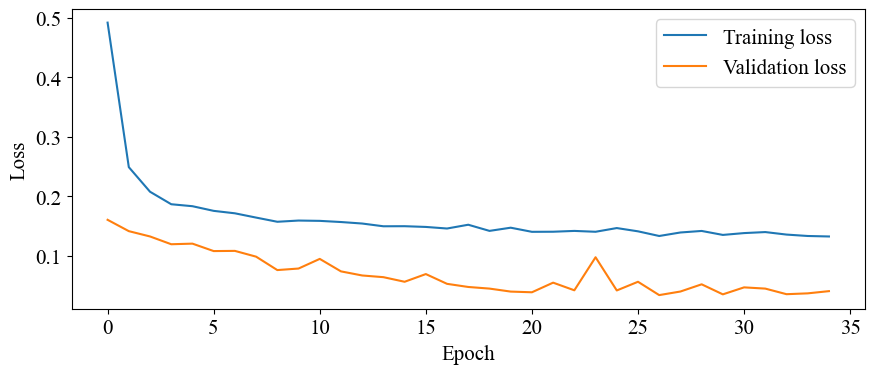

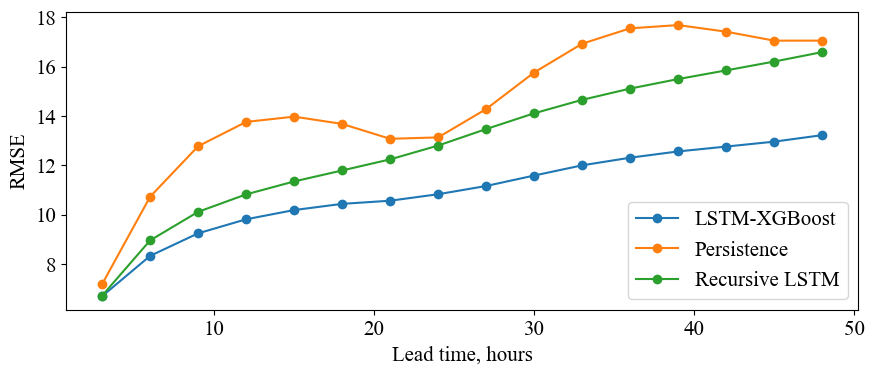

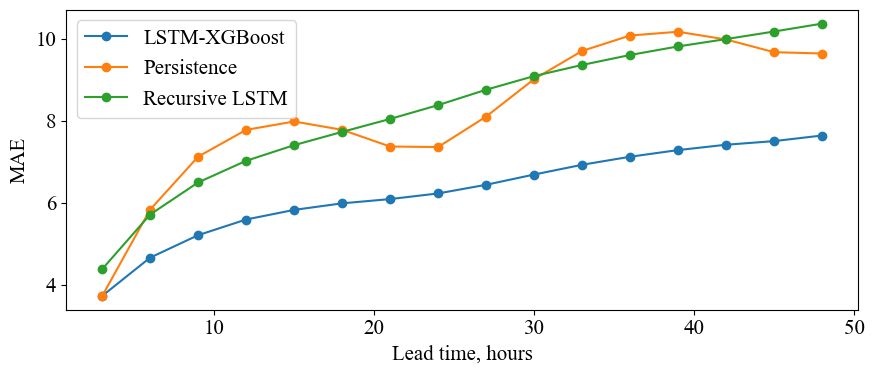

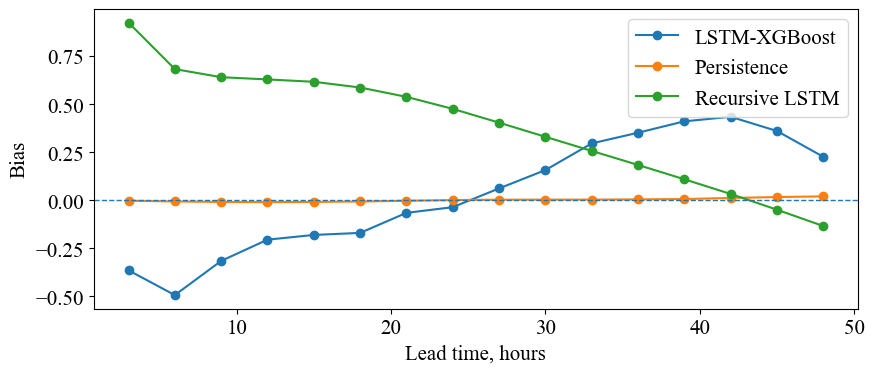

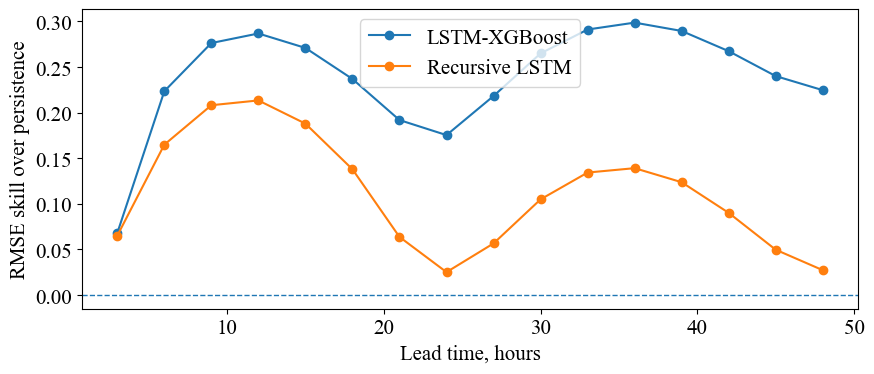

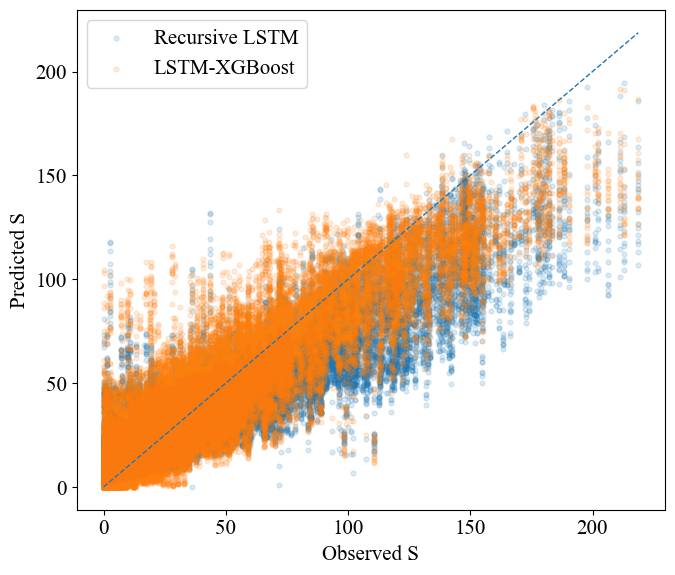


SAVED OUTPUTS
Output folder: C:\Users\sh1345\code\myproject\Project 1\Python and keras scripts\recursive_lstm_xgboost_outputs\history56_horizon16_3hourly_reduced_weather
Peak threshold: 78.66419573679573
Done.


In [13]:



# ============================================================
# 17. PLOTS
# ============================================================

# Training history
plt.figure(figsize=(9, 4))
plt.plot(training_history.history["loss"], label="Training loss")
plt.plot(training_history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "training_history.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# RMSE by lead
plt.figure(figsize=(9, 4))
for model_name, group in test_lead.groupby("model"):
    plt.plot(
        group["lead_hours"],
        group["RMSE"],
        marker="o",
        label=model_name,
    )
plt.xlabel("Lead time, hours")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "test_rmse_by_lead.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# MAE by lead
plt.figure(figsize=(9, 4))
for model_name, group in test_lead.groupby("model"):
    plt.plot(
        group["lead_hours"],
        group["MAE"],
        marker="o",
        label=model_name,
    )
plt.xlabel("Lead time, hours")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "test_mae_by_lead.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# Bias by lead
plt.figure(figsize=(9, 4))
for model_name, group in test_lead.groupby("model"):
    plt.plot(
        group["lead_hours"],
        group["Bias"],
        marker="o",
        label=model_name,
    )
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Lead time, hours")
plt.ylabel("Bias")
plt.legend()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "test_bias_by_lead.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# RMSE skill over persistence
skill_plot = test_lead_skill.loc[
    test_lead_skill["model"] != "Persistence"
].copy()

plt.figure(figsize=(9, 4))
for model_name, group in skill_plot.groupby("model"):
    plt.plot(
        group["lead_hours"],
        group["RMSE_skill_over_persistence"],
        marker="o",
        label=model_name,
    )
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Lead time, hours")
plt.ylabel("RMSE skill over persistence")
plt.legend()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "test_rmse_skill_over_persistence.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# Observed vs predicted
plt.figure(figsize=(7, 6))
plt.scatter(
    test_results["y_true"],
    test_results["lstm_pred"],
    alpha=0.15,
    s=12,
    label="Recursive LSTM",
)
plt.scatter(
    test_results["y_true"],
    test_results["hybrid_pred"],
    alpha=0.15,
    s=12,
    label="LSTM-XGBoost",
)

plot_min = min(
    test_results["y_true"].min(),
    test_results["lstm_pred"].min(),
    test_results["hybrid_pred"].min(),
)
plot_max = max(
    test_results["y_true"].max(),
    test_results["lstm_pred"].max(),
    test_results["hybrid_pred"].max(),
)

plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
    linewidth=1,
)
plt.xlabel("Observed S")
plt.ylabel("Predicted S")
plt.legend()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "test_observed_vs_predicted.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# ============================================================
# 18. FINAL SUMMARY
# ============================================================

print_heading("SAVED OUTPUTS")
print("Output folder:", OUTPUT_DIR.resolve())
print("Peak threshold:", PEAK_THRESHOLD)
print("Done.")


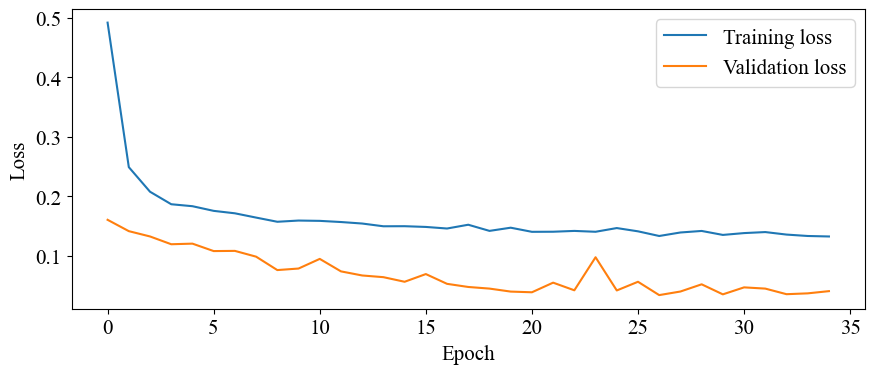

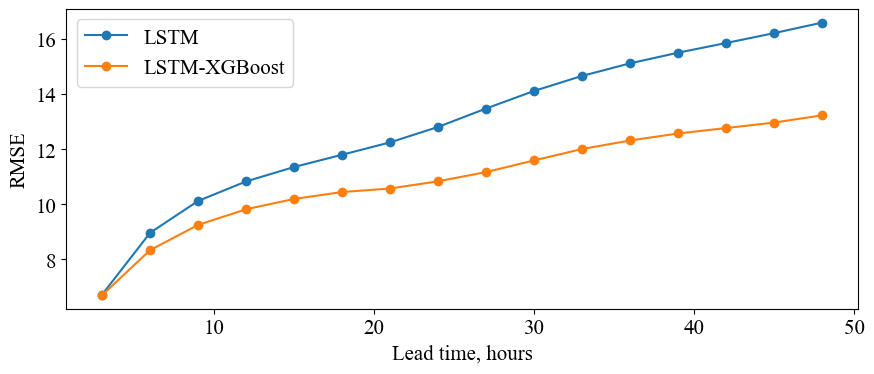

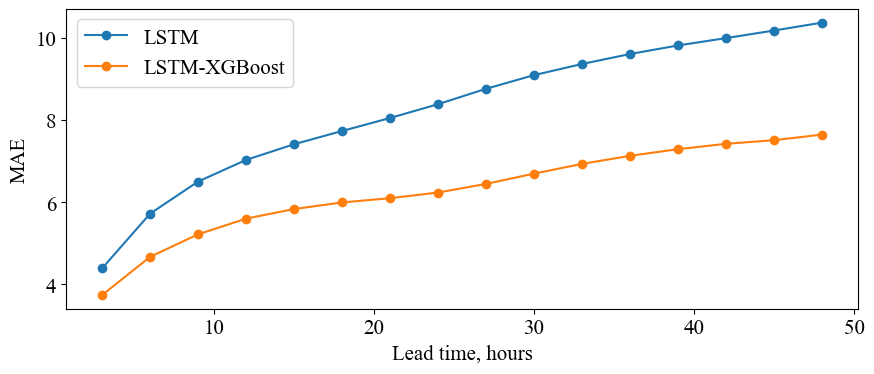

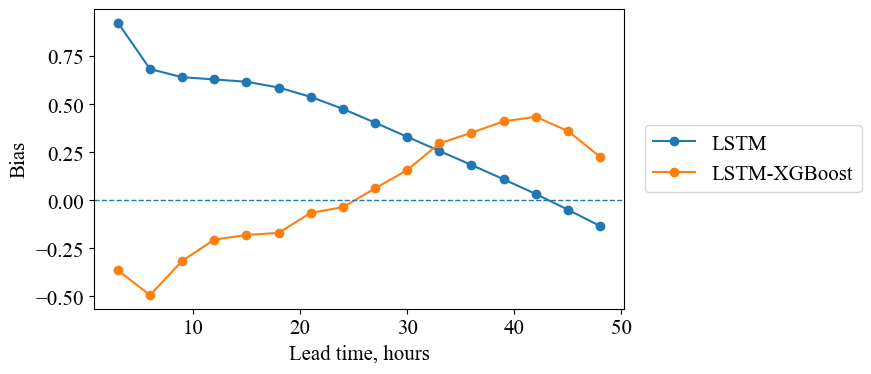

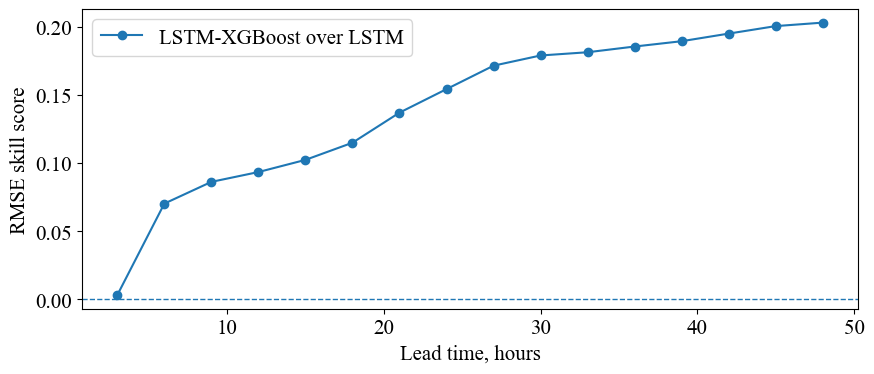

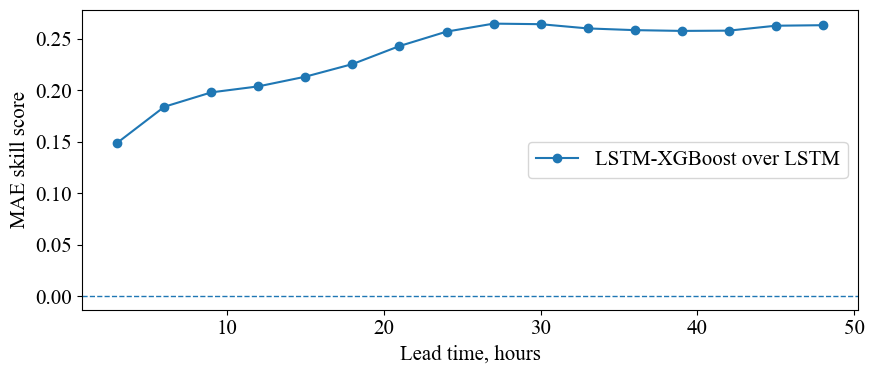

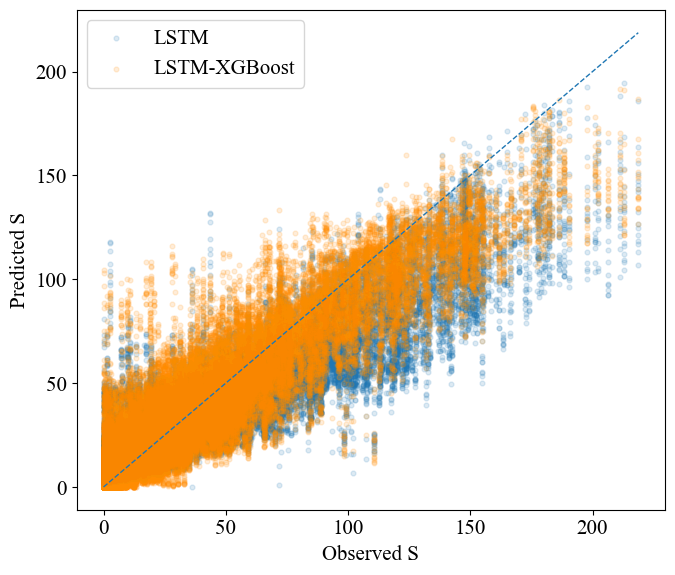

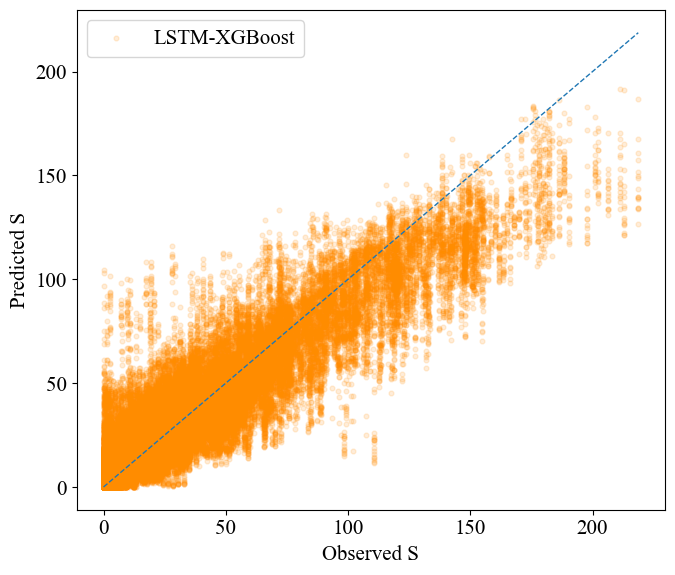

In [14]:
# ============================================================
# 18. PLOTS: comparing LSTM vs LSTM-XGBoost
# ============================================================

# Standardise model names for publication-style plots
test_lead_plot = test_lead.copy()
test_lead_plot["model"] = test_lead_plot["model"].replace({
    "Recursive LSTM": "LSTM",
    "LSTM-XGBoost": "LSTM-XGBoost",
})

test_results_plot = test_results.copy()

COMPARE_MODELS = ["LSTM", "LSTM-XGBoost"]

test_lead_compare = test_lead_plot.loc[
    test_lead_plot["model"].isin(COMPARE_MODELS)
].copy()


# ----------------------------
# Training history
# ----------------------------
plt.figure(figsize=(9, 4))
plt.plot(training_history.history["loss"], label="Training loss")
plt.plot(training_history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "training_history.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# ----------------------------
# RMSE by lead: LSTM vs LSTM-XGBoost
# ----------------------------
plt.figure(figsize=(9, 4))
for model_name, group in test_lead_compare.groupby("model"):
    plt.plot(
        group["lead_hours"],
        group["RMSE"],
        marker="o",
        label=model_name,
    )

plt.xlabel("Lead time, hours")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "test_rmse_by_lead_lstm_vs_lstm_xgboost.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# ----------------------------
# MAE by lead: LSTM vs LSTM-XGBoost
# ----------------------------
plt.figure(figsize=(9, 4))
for model_name, group in test_lead_compare.groupby("model"):
    plt.plot(
        group["lead_hours"],
        group["MAE"],
        marker="o",
        label=model_name,
    )

plt.xlabel("Lead time, hours")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "test_mae_by_lead_lstm_vs_lstm_xgboost.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# ----------------------------
# Bias by lead: LSTM vs LSTM-XGBoost
# ----------------------------
plt.figure(figsize=(9, 4))
for model_name, group in test_lead_compare.groupby("model"):
    plt.plot(
        group["lead_hours"],
        group["Bias"],
        marker="o",
        label=model_name,
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Lead time, hours")
plt.ylabel("Bias")
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "test_bias_by_lead_lstm_vs_lstm_xgboost.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# ----------------------------
# RMSE skill of LSTM-XGBoost over LSTM
# positive means LSTM-XGBoost is better
# ----------------------------
lstm_rmse = test_lead_compare.loc[
    test_lead_compare["model"] == "LSTM",
    ["lead_step", "lead_hours", "RMSE"]
].rename(columns={"RMSE": "RMSE_lstm"})

xgb_rmse = test_lead_compare.loc[
    test_lead_compare["model"] == "LSTM-XGBoost",
    ["lead_step", "lead_hours", "RMSE"]
].rename(columns={"RMSE": "RMSE_lstm_xgboost"})

rmse_compare = lstm_rmse.merge(
    xgb_rmse,
    on=["lead_step", "lead_hours"],
    how="inner",
)

rmse_compare["RMSE_skill_lstm_xgboost_over_lstm"] = (
    1.0 - rmse_compare["RMSE_lstm_xgboost"] / rmse_compare["RMSE_lstm"]
)

plt.figure(figsize=(9, 4))
plt.plot(
    rmse_compare["lead_hours"],
    rmse_compare["RMSE_skill_lstm_xgboost_over_lstm"],
    marker="o",
    label="LSTM-XGBoost over LSTM",
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Lead time, hours")
plt.ylabel("RMSE skill score")
plt.legend()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "test_rmse_skill_lstm_xgboost_over_lstm.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# ----------------------------
# MAE skill of LSTM-XGBoost over LSTM
# positive means LSTM-XGBoost is better
# ----------------------------
lstm_mae = test_lead_compare.loc[
    test_lead_compare["model"] == "LSTM",
    ["lead_step", "lead_hours", "MAE"]
].rename(columns={"MAE": "MAE_lstm"})

xgb_mae = test_lead_compare.loc[
    test_lead_compare["model"] == "LSTM-XGBoost",
    ["lead_step", "lead_hours", "MAE"]
].rename(columns={"MAE": "MAE_lstm_xgboost"})

mae_compare = lstm_mae.merge(
    xgb_mae,
    on=["lead_step", "lead_hours"],
    how="inner",
)

mae_compare["MAE_skill_lstm_xgboost_over_lstm"] = (
    1.0 - mae_compare["MAE_lstm_xgboost"] / mae_compare["MAE_lstm"]
)

plt.figure(figsize=(9, 4))
plt.plot(
    mae_compare["lead_hours"],
    mae_compare["MAE_skill_lstm_xgboost_over_lstm"],
    marker="o",
    label="LSTM-XGBoost over LSTM",
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Lead time, hours")
plt.ylabel("MAE skill score")
plt.legend()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "test_mae_skill_lstm_xgboost_over_lstm.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# ----------------------------
# Observed vs predicted: LSTM and LSTM-XGBoost together
# ----------------------------
plt.figure(figsize=(7, 6))

plt.scatter(
    test_results_plot["y_true"],
    test_results_plot["lstm_pred"],
    alpha=0.15,
    s=12,
    label="LSTM",
)

plt.scatter(
    test_results_plot["y_true"],
    test_results_plot["hybrid_pred"],
    alpha=0.15,
    s=12,
    label="LSTM-XGBoost",
    color="darkorange"
)

plot_min = min(
    test_results_plot["y_true"].min(),
    test_results_plot["lstm_pred"].min(),
    test_results_plot["hybrid_pred"].min(),
)

plot_max = max(
    test_results_plot["y_true"].max(),
    test_results_plot["lstm_pred"].max(),
    test_results_plot["hybrid_pred"].max(),
)

plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
    linewidth=1,
)

plt.xlabel("Observed S")
plt.ylabel("Predicted S")
plt.legend()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "test_observed_vs_predicted_lstm_vs_lstm_xgboost.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# ----------------------------
# Observed vs predicted: LSTM-XGBoost alone
# ----------------------------
plt.figure(figsize=(7, 6))

plt.scatter(
    test_results_plot["y_true"],
    test_results_plot["hybrid_pred"],
    alpha=0.15,
    s=12,
    label="LSTM-XGBoost",
    color="darkorange"
)

plot_min = min(
    test_results_plot["y_true"].min(),
    test_results_plot["hybrid_pred"].min(),
)

plot_max = max(
    test_results_plot["y_true"].max(),
    test_results_plot["hybrid_pred"].max(),
)

plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
    linewidth=1,

)

plt.xlabel("Observed S")
plt.ylabel("Predicted S")
plt.legend()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "test_observed_vs_predicted_lstm_xgboost_only.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()